<a href="https://colab.research.google.com/github/mopuriapurva/DSA0404-FODS/blob/main/ASSESSMENT%20TOOLS/CO2-AT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== RAW DATA ==========
  Employee_Name   Department   Salary   Join_Date
0        Alice            HR  50000.0  2022-01-15
1           Bob  Engineering  85000.0  2021-06-20
2       Charlie           HR      NaN  2023-03-11
3         Diana  Engineering  92000.0  2020-11-01
4          Evan    Marketing  60000.0  2024-02-28

========== PREPROCESSED DATA ==========
  Employee_Name   Department   Salary  Join_Date  Years_of_Service
0         Alice           HR  50000.0 2022-01-15                 4
1           Bob  Engineering  85000.0 2021-06-20                 5
2       Charlie           HR  72500.0 2023-03-11                 3
3         Diana  Engineering  92000.0 2020-11-01                 6
4          Evan    Marketing  60000.0 2024-02-28                 2

========== DEPARTMENT SUMMARY ==========
    Department  Avg_Salary  Total_Employees
0  Engineering     88500.0                2
1           HR     61250.0                2
2    Marketing     60000.0                1


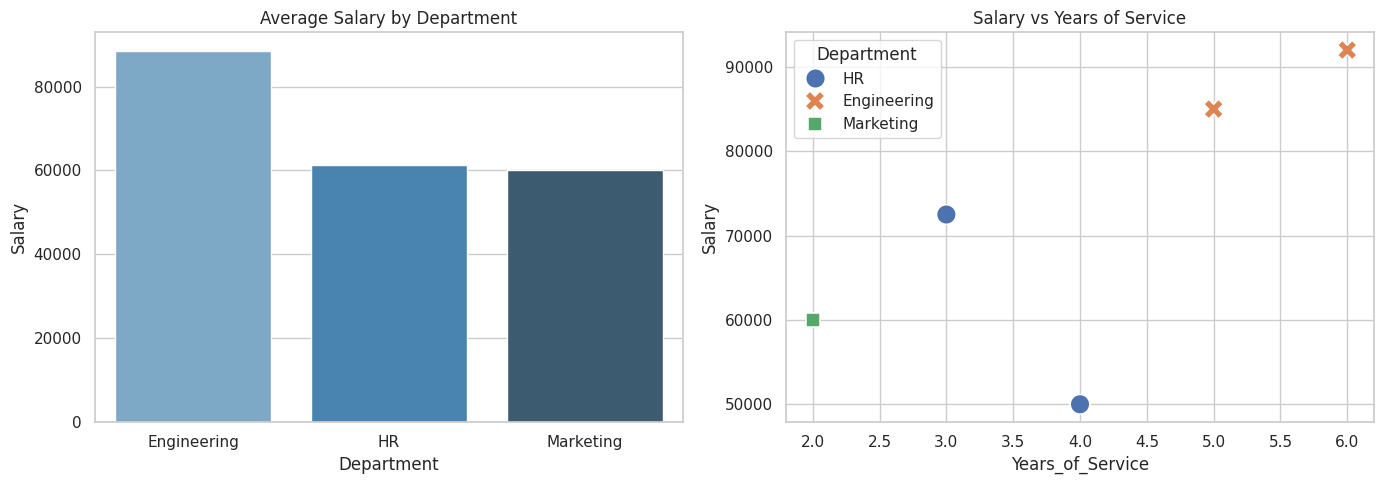


========== SAMPLE DATAFRAME ==========
     Name  Age  Student
0    John   20     True
1    Emma   19     True
2    Liam   21    False
3  Olivia   18     True

========== AFTER ADDING ROW ==========
     Name  Age  Student
0    John   20     True
1    Emma   19     True
2    Liam   21    False
3  Olivia   18     True
4  Sophia   22    False

========== SCIPY STATISTICS ==========
Mean : 30.0
Median : 30.0
Mode : ModeResult(mode=np.int64(10), count=np.int64(1))

Probability (X <= 85): 0.9331927987311419

T Statistic : -0.2049800154226962
P Value : 0.8456711339658732

Correlation : 1.0

Solution of Linear Equations : [0.  2.5]

Minimum occurs at : [-2.62955131e-08]

========== LOGISTIC REGRESSION ==========
Accuracy : 1.0

========== KMEANS CLUSTERING ==========
Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2

In [1]:
# =====================================================
# Install required libraries (Run once in Google Colab)
# =====================================================
!pip -q install scipy scikit-learn seaborn

# =====================================================
# Import Libraries
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats, linalg
from scipy.stats import norm, pearsonr
from scipy.optimize import minimize

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

# =====================================================
# PART 1 : Employee Data Analysis
# =====================================================

raw_data = {
    "Employee_Name": [" Alice ", "Bob", "Charlie", "Diana", "Evan"],
    "Department": ["HR", "Engineering", "HR", "Engineering", "Marketing"],
    "Salary": [50000, 85000, np.nan, 92000, 60000],
    "Join_Date": [
        "2022-01-15",
        "2021-06-20",
        "2023-03-11",
        "2020-11-01",
        "2024-02-28",
    ],
}

df = pd.DataFrame(raw_data)

print("========== RAW DATA ==========")
print(df)

# =====================================================
# Data Preprocessing
# =====================================================

# Remove extra spaces
df["Employee_Name"] = df["Employee_Name"].str.strip()

# Fill missing salary
median_salary = df["Salary"].median()
df["Salary"] = df["Salary"].fillna(median_salary)

# Convert to datetime
df["Join_Date"] = pd.to_datetime(df["Join_Date"])

# Create Years of Service
df["Years_of_Service"] = 2026 - df["Join_Date"].dt.year

print("\n========== PREPROCESSED DATA ==========")
print(df)

# =====================================================
# Aggregation
# =====================================================

dept_summary = (
    df.groupby("Department")
      .agg(
          Avg_Salary=("Salary", "mean"),
          Total_Employees=("Employee_Name", "count")
      )
      .reset_index()
)

print("\n========== DEPARTMENT SUMMARY ==========")
print(dept_summary)

# =====================================================
# Visualization
# =====================================================

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1,2,figsize=(14,5))

sns.barplot(
    data=dept_summary,
    x="Department",
    y="Avg_Salary",
    hue="Department",
    palette="Blues_d",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Average Salary by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Salary")

sns.scatterplot(
    data=df,
    x="Years_of_Service",
    y="Salary",
    hue="Department",
    style="Department",
    s=200,
    ax=axes[1]
)

axes[1].set_title("Salary vs Years of Service")

plt.tight_layout()
plt.show()

# =====================================================
# PART 2 : Creating DataFrame
# =====================================================

print("\n========== SAMPLE DATAFRAME ==========")

students = pd.DataFrame({
    "Name":["John","Emma","Liam","Olivia"],
    "Age":[20,19,21,18],
    "Student":[True,True,False,True]
})

print(students)

# =====================================================
# Add New Row
# =====================================================

new_row = pd.DataFrame({
    "Name":["Sophia"],
    "Age":[22],
    "Student":[False]
})

students = pd.concat([students,new_row],ignore_index=True)

print("\n========== AFTER ADDING ROW ==========")
print(students)

# =====================================================
# PART 3 : SciPy Statistics
# =====================================================

print("\n========== SCIPY STATISTICS ==========")

data = [10,20,30,40,50]

print("Mean :", np.mean(data))
print("Median :", np.median(data))
print("Mode :", stats.mode(data))

# =====================================================
# Probability Distribution
# =====================================================

probability = norm.cdf(85, loc=70, scale=10)

print("\nProbability (X <= 85):", probability)

# =====================================================
# Hypothesis Testing
# =====================================================

sample = [22,25,19,24,28,30]

t_stat, p_value = stats.ttest_1samp(sample,25)

print("\nT Statistic :", t_stat)
print("P Value :", p_value)

# =====================================================
# Correlation
# =====================================================

x = [1,2,3,4,5]
y = [2,4,6,8,10]

corr, p = pearsonr(x,y)

print("\nCorrelation :", corr)

# =====================================================
# Linear Algebra
# =====================================================

A = [[3,2],[1,2]]
B = [5,5]

solution = linalg.solve(A,B)

print("\nSolution of Linear Equations :", solution)

# =====================================================
# Optimization
# =====================================================

def objective(x):
    return x**2 + 4

result = minimize(objective, x0=5)

print("\nMinimum occurs at :", result.x)

# =====================================================
# PART 4 : Logistic Regression
# =====================================================

print("\n========== LOGISTIC REGRESSION ==========")

iris = datasets.load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)

print("Accuracy :", accuracy)

# =====================================================
# PART 5 : KMeans Clustering
# =====================================================

print("\n========== KMEANS CLUSTERING ==========")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans.fit(iris.data)

print("Cluster Labels:")
print(kmeans.labels_)